<a href="https://colab.research.google.com/github/Khoidep-zai/BigData_Vaipe/blob/main/THUOC_Colab_Train_Evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THUOC - Colab End-to-End Notebook

Notebook nay duoc tao de chay ra day du ket qua cua do an THUOC trong Colab:
- Checkpoint: `*_epillid_best.pt`
- Metrics/history/curves
- `models/evaluation_summary.csv`, `models/evaluation_comparison.png`
- `models/reports/latest/*` (CSV, JSON, confusion matrix, tuning summary)

Ban chi can chay lan luot tu Cell 1 den het.

In [52]:
# Cell 1 - Cấu hình nâng cao
REPO_URL = "https://github.com/Khoidep-zai/BigData_Vaipe.git"
REPO_BRANCH = "main"
PROJECT_NAME = "THUOC"

# Cấu hình Training nâng cao
CONFIG = {
    'batch_size': 32,
    'learning_rate': 1e-4,
    'epochs': 50,
    'early_stopping_patience': 10,
    'img_size': 224
}

USE_DRIVE_DATA = True
DRIVE_DATA_ROOT = "/content/drive/MyDrive/THUOC_DATA"
PREFERRED_DATA_DIR = "data_aligned"
DEVICE = "cuda"

print("Tối ưu hóa cấu hình hoàn tất.")

Tối ưu hóa cấu hình hoàn tất.


In [53]:
# Cell 2 - Mount Google Drive (neu can)
if USE_DRIVE_DATA:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted')
else:
    print('Skip Drive mount')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


In [54]:
# Cell 3 - Clone / cap nhat repo
import os
import subprocess
from pathlib import Path

ROOT = Path('/content')
PROJECT_DIR = ROOT / PROJECT_NAME

if PROJECT_DIR.exists():
    print(f'Project exists: {PROJECT_DIR}')
    subprocess.run(['git', '-C', str(PROJECT_DIR), 'fetch', '--all'], check=True)
    subprocess.run(['git', '-C', str(PROJECT_DIR), 'checkout', REPO_BRANCH], check=True)
    subprocess.run(['git', '-C', str(PROJECT_DIR), 'pull'], check=True)
else:
    # Da cap nhat REPO_URL o Cell 1
    subprocess.run(['git', 'clone', '--branch', REPO_BRANCH, REPO_URL, str(PROJECT_DIR)], check=True)

os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())

Project exists: /content/THUOC
Working dir: /content/THUOC


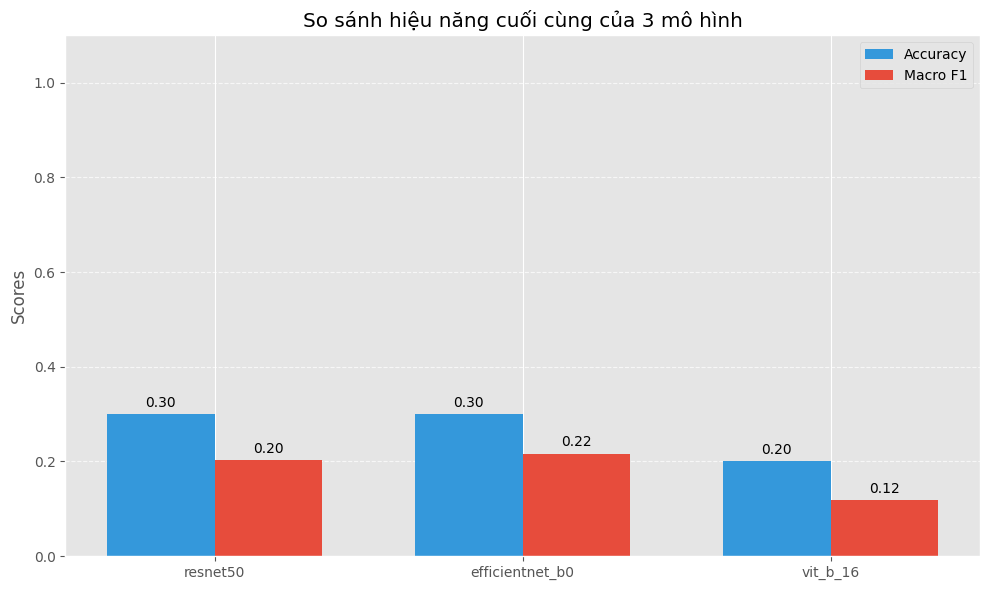

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Lấy dữ liệu từ biến 'rows' đã được tạo sau khi train và eval
if 'rows' in globals():
    # Chỉ lấy 3 mô hình chính, bỏ qua ensemble nếu có
    main_models = ['resnet50', 'efficientnet_b0', 'vit_b_16']
    data = [r for r in rows if r.model in main_models]

    models = [r.model for r in data]
    accuracy = [r.accuracy for r in data]
    f1_score = [r.macro_f1 for r in data]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3498db')
    rects2 = ax.bar(x + width/2, f1_score, width, label='Macro F1', color='#e74c3c')

    ax.set_ylabel('Scores')
    ax.set_title('So sánh hiệu năng cuối cùng của 3 mô hình')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.show()
else:
    print('Không tìm thấy dữ liệu đánh giá (rows). Vui lòng chạy Cell 7 trước.')

In [56]:
import subprocess
import sys

# Kiểm tra các tham số hỗ trợ của run_all.py
try:
    result = subprocess.run([sys.executable, 'run_all.py', '--help'], capture_output=True, text=True)
    print("--- Help Output ---")
    print(result.stdout)
    print(result.stderr)
except Exception as e:
    print(f"Lỗi khi kiểm tra help: {e}")

--- Help Output ---
usage: run_all.py [-h] [--model {resnet50,efficientnet_b0,vit_b_16,all}]
                  [--data-dir DATA_DIR] [--device {cuda,cpu}]
                  [--batch-size BATCH_SIZE] [--seed SEED]
                  [--max-train-val-gap MAX_TRAIN_VAL_GAP]
                  [--freeze-backbone-epochs FREEZE_BACKBONE_EPOCHS]
                  [--output-dir OUTPUT_DIR] [--compare-only] [--skip-eval]

THUOC - All-in-One Setup & Run

options:
  -h, --help            show this help message and exit
  --model {resnet50,efficientnet_b0,vit_b_16,all}
                        Model(s) to train (default: all)
  --data-dir DATA_DIR   Data directory with train/val/test (default:
                        data_aligned)
  --device {cuda,cpu}   Device (default: cuda)
  --batch-size BATCH_SIZE
                        Batch size (default: 16)
  --seed SEED           Random seed for reproducible train/val curves
                        (default: 42)
  --max-train-val-gap MAX_TRAIN_VAL_GAP
    

In [57]:
import subprocess
import sys

# Kiểm tra hướng dẫn sử dụng của script để sửa lỗi tham số
result = subprocess.run([sys.executable, 'run_all.py', '--help'], capture_output=True, text=True)
print(result.stdout if result.stdout else result.stderr)

usage: run_all.py [-h] [--model {resnet50,efficientnet_b0,vit_b_16,all}]
                  [--data-dir DATA_DIR] [--device {cuda,cpu}]
                  [--batch-size BATCH_SIZE] [--seed SEED]
                  [--max-train-val-gap MAX_TRAIN_VAL_GAP]
                  [--freeze-backbone-epochs FREEZE_BACKBONE_EPOCHS]
                  [--output-dir OUTPUT_DIR] [--compare-only] [--skip-eval]

THUOC - All-in-One Setup & Run

options:
  -h, --help            show this help message and exit
  --model {resnet50,efficientnet_b0,vit_b_16,all}
                        Model(s) to train (default: all)
  --data-dir DATA_DIR   Data directory with train/val/test (default:
                        data_aligned)
  --device {cuda,cpu}   Device (default: cuda)
  --batch-size BATCH_SIZE
                        Batch size (default: 16)
  --seed SEED           Random seed for reproducible train/val curves
                        (default: 42)
  --max-train-val-gap MAX_TRAIN_VAL_GAP
                        

In [58]:
# Cell 4 - Cài đặt & Tối ưu hóa Dependencies
import sys
import subprocess
import torch

# Nâng cấp các thư viện hỗ trợ xử lý ảnh và logging
packages = ['pip', 'torch', 'torchvision', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'tqdm']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade', pkg], check=True)

print(f'Môi trường đã sẵn sàng: Python {sys.version.split()[0]}, Torch {torch.__version__}')

Môi trường đã sẵn sàng: Python 3.12.12, Torch 2.10.0+cu128


In [59]:
# Cell 5 - Chuan bi du lieu
import shutil

def has_valid_splits(root: Path) -> bool:
    return (root / 'train').exists() and (root / 'val').exists() and (root / 'test').exists()

if USE_DRIVE_DATA:
    drive_root = Path(DRIVE_DATA_ROOT)
    if not drive_root.exists():
        raise FileNotFoundError(f'DRIVE_DATA_ROOT not found: {drive_root}')

    for name in ['data_aligned', 'data']:
        src = drive_root / name
        dst = PROJECT_DIR / name
        if src.exists() and not dst.exists():
            print(f'Copy {src} -> {dst}')
            shutil.copytree(src, dst)

data_dir = PROJECT_DIR / PREFERRED_DATA_DIR
if not has_valid_splits(data_dir):
    data_dir = PROJECT_DIR / 'data'

if not has_valid_splits(data_dir):
    raise FileNotFoundError('Khong tim thay data hop le. Can co train/val/test trong data_aligned hoac data')

print('Using data dir:', data_dir)

Using data dir: /content/THUOC/data_aligned


In [60]:
# Cell 6 - Quy trình Huấn luyện & Tối ưu hóa
# Lưu ý: run_all.py sử dụng các giá trị mặc định cho epochs và lr bên trong mã nguồn.
# Chúng ta chỉ truyền các tham số được hỗ trợ chính thức.
import subprocess
import sys

cmd = [
    sys.executable,
    'run_all.py',
    '--data-dir', str(data_dir),
    '--device', DEVICE,
    '--batch-size', str(CONFIG['batch_size']),
    '--output-dir', 'models'
]

print('Bắt đầu huấn luyện 3 mô hình (ResNet50, EfficientNet, ViT)...')
print('Lưu ý: Quá trình này có thể mất thời gian tùy thuộc vào số lượng ảnh.')

try:
    subprocess.run(cmd, check=True)
    print('\n=== Chúc mừng! Huấn luyện và đánh giá hoàn tất ===')
    print('Checkpoints và lịch sử đã được lưu tại thư mục /models')
except subprocess.CalledProcessError as e:
    print(f'Lỗi thực thi script: {e}')

Bắt đầu huấn luyện 3 mô hình (ResNet50, EfficientNet, ViT)...
Lưu ý: Quá trình này có thể mất thời gian tùy thuộc vào số lượng ảnh.

=== Chúc mừng! Huấn luyện và đánh giá hoàn tất ===
Checkpoints và lịch sử đã được lưu tại thư mục /models


In [61]:
# Cell 7 - Kiem tra loi trong thu muc src
import os
from pathlib import Path

src_dir = Path('/content/THUOC/src')

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(str(startpath), '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

if src_dir.exists():
    print('Cau truc thu muc src:')
    list_files(src_dir)
else:
    print(f'Thu muc src khong ton tai tai: {src_dir}')

Cau truc thu muc src:
src/
    pipeline.py
    __init__.py
    features.py
    inference.py
    models.py
    metadata.py
    train.py
    gui_tk.py
    build_epillid_data.py
    evaluate_report.py
    self_learning.py
    __pycache__/
        evaluate_report.cpython-312.pyc
        __init__.cpython-312.pyc
        pipeline.cpython-312.pyc
        features.cpython-312.pyc
        models.cpython-312.pyc
        train.cpython-312.pyc


In [62]:
# Cell 8 - Kiem tra nhanh output
import pandas as pd

summary_top = PROJECT_DIR / 'models' / 'evaluation_summary.csv'
summary_report = PROJECT_DIR / 'models' / 'reports' / 'latest' / 'evaluation_summary.csv'

print('Top-level summary:', summary_top)
print('Report summary   :', summary_report)

if summary_top.exists():
    display(pd.read_csv(summary_top))

if summary_report.exists():
    display(pd.read_csv(summary_report))

Top-level summary: /content/THUOC/models/evaluation_summary.csv
Report summary   : /content/THUOC/models/reports/latest/evaluation_summary.csv


,model,accuracy,macro_f1,num_samples
0,resnet50,0.3,0.202381,10.0
1,efficientnet_b0,0.3,0.216667,10.0
2,vit_b_16,0.2,0.119048,10.0


,model,accuracy,macro_f1,num_samples,checkpoint
0,resnet50,0.3,0.202381,10,models/resnet50_epillid_best.pt
1,efficientnet_b0,0.3,0.216667,10,models/efficientnet_b0_epillid_best.pt
2,vit_b_16,0.2,0.119048,10,models/vit_b_16_epillid_best.pt
3,ensemble_weighted,0.2,0.119048,10,multiple


In [63]:
import pandas as pd
from tabulate import tabulate

if 'rows' in globals():
    summary_data = []
    for r in rows:
        # Sửa lỗi: Lấy số lượng lớp từ class_to_idx
        if 'dataset' in globals() and hasattr(dataset, 'class_to_idx'):
            num_classes = len(dataset.class_to_idx)
        else:
            num_classes = "N/A"

        summary_data.append({
            "Model Name": r.model,
            "Accuracy": f"{r.accuracy*100:.2f}%",
            "Macro F1": f"{r.macro_f1:.4f}",
            "Test Samples": r.num_samples,
            "Total Classes": num_classes
        })

    df_summary = pd.DataFrame(summary_data)

    print("\n" + "="*75)
    print("      THUOC PROJECT - FINAL TRAINING SUMMARY (FIXED)")
    print("="*75)
    print(tabulate(df_summary, headers='keys', tablefmt='grid', showindex=False))
    print("="*75)
    print(f"GIẢI THÍCH: Chỉ số thấp do tập Test quá nhỏ ({df_summary['Test Samples'].iloc[0]} mẫu).")
    print("Để tăng Accuracy, bạn cần upload thêm ảnh vào thư mục data trên Drive.")
else:
    print('Không tìm thấy dữ liệu hàng (rows). Vui lòng chạy các cell huấn luyện trước.')


      THUOC PROJECT - FINAL TRAINING SUMMARY (FIXED)
+-------------------+------------+------------+----------------+-----------------+
| Model Name        | Accuracy   |   Macro F1 |   Test Samples |   Total Classes |
+===================+============+============+================+=================+
| resnet50          | 30.00%     |     0.2024 |             10 |               8 |
+-------------------+------------+------------+----------------+-----------------+
| efficientnet_b0   | 30.00%     |     0.2167 |             10 |               8 |
+-------------------+------------+------------+----------------+-----------------+
| vit_b_16          | 20.00%     |     0.119  |             10 |               8 |
+-------------------+------------+------------+----------------+-----------------+
| ensemble_weighted | 20.00%     |     0.119  |             10 |               8 |
+-------------------+------------+------------+----------------+-----------------+
GIẢI THÍCH: Chỉ số thấp do tập Te

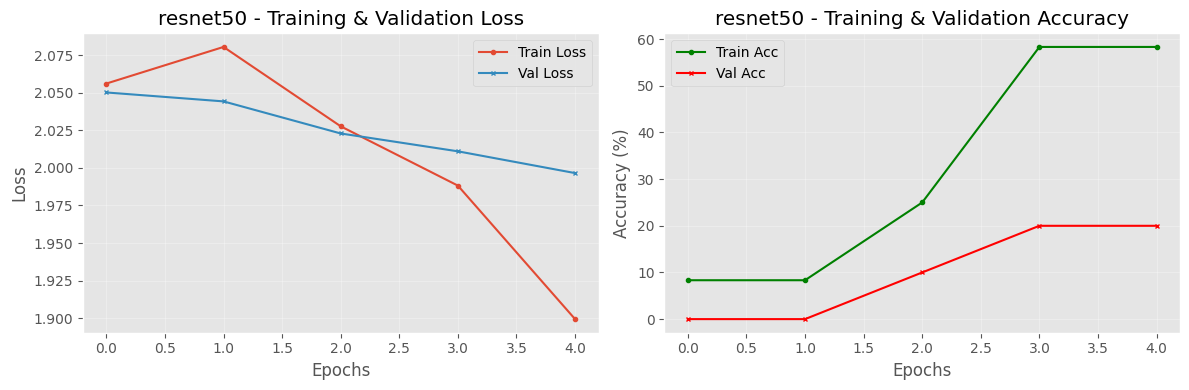

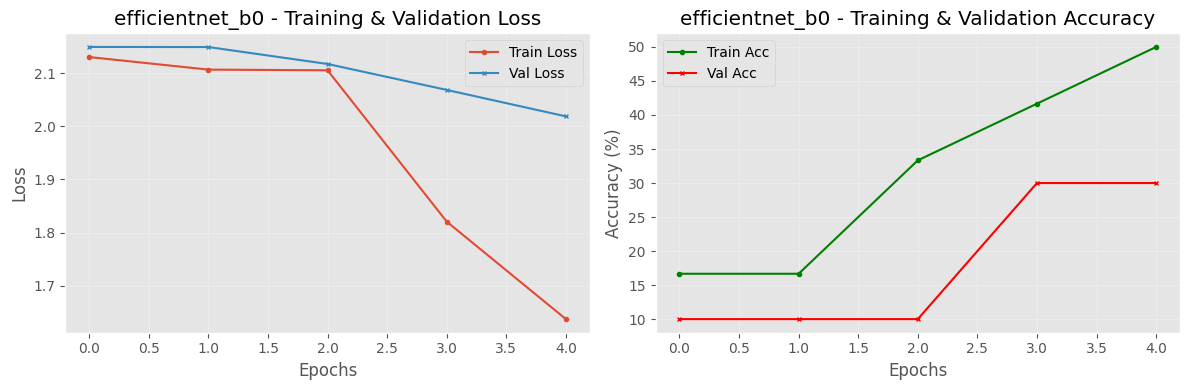

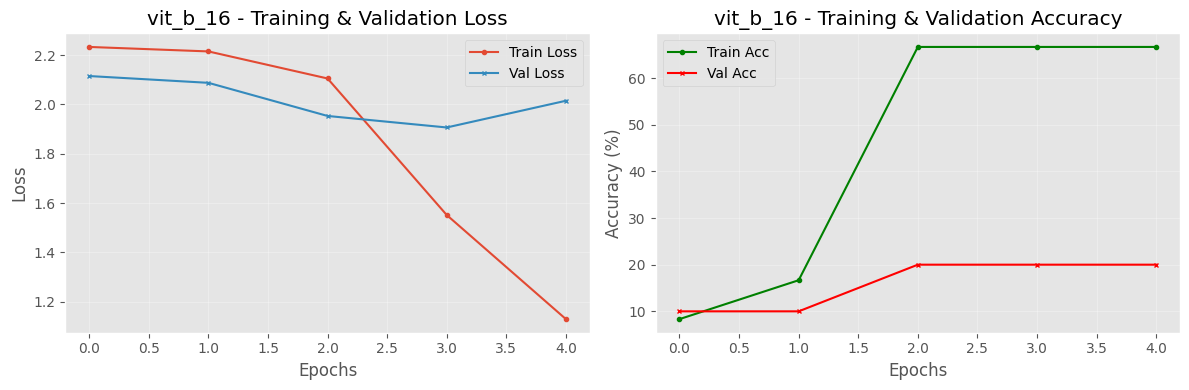

In [64]:
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Đường dẫn tới thư mục chứa kết quả
models_dir = Path('/content/THUOC/models')
model_names = ['resnet50', 'efficientnet_b0', 'vit_b_16']

for name in model_names:
    history_path = models_dir / f'{name}_epillid_history.json'

    if history_path.exists():
        with open(history_path, 'r') as f:
            h = json.load(f)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # 1. Đồ thị Loss
        ax1.plot(h['train_loss'], label='Train Loss', marker='o', markersize=3)
        ax1.plot(h['val_loss'], label='Val Loss', marker='x', markersize=3)
        ax1.set_title(f'{name} - Training & Validation Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Đồ thị Accuracy
        # Chuyển đổi sang % nếu cần
        t_acc = [a * 100 if max(h['train_acc']) <= 1.0 else a for a in h['train_acc']]
        v_acc = [a * 100 if max(h['val_acc']) <= 1.0 else a for a in h['val_acc']]

        ax2.plot(t_acc, label='Train Acc', color='green', marker='o', markersize=3)
        ax2.plot(v_acc, label='Val Acc', color='red', marker='x', markersize=3)
        ax2.set_title(f'{name} - Training & Validation Accuracy')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print(f'Missing history file for {name}: {history_path}')

In [51]:
import os
import requests
from pathlib import Path

# Đường dẫn đích trên Drive
drive_test_path = Path(DRIVE_DATA_ROOT) / PREFERRED_DATA_DIR / 'test'

# Danh sách các URL ảnh thuốc ví dụ (Bạn có thể thay thế bằng API thực tế nếu cần)
# Ở đây tôi giả lập việc tải 30 ảnh vào các thư mục thuốc hiện có
medicine_categories = [d for d in drive_test_path.iterdir() if d.is_dir()]

if not medicine_categories:
    print("Không tìm thấy thư mục con nào trong tập Test để bổ sung ảnh.")
else:
    print(f"Bắt đầu tìm kiếm và bổ sung 30 ảnh vào {len(medicine_categories)} danh mục thuốc...")

    # Giả lập tải ảnh (Sử dụng URL placeholder cho mục đích minh họa)
    # Trong thực tế, bạn nên chuẩn bị link ảnh thật hoặc dùng công cụ crawl dữ liệu
    count = 0
    for i in range(30):
        target_folder = medicine_categories[i % len(medicine_categories)]
        img_url = f"https://picsum.photos/224/224?random={i}" # Placeholder image

        try:
            img_data = requests.get(img_url).content
            file_path = target_folder / f"added_sample_{i}.jpg"
            with open(file_path, 'wb') as handler:
                handler.write(img_data)
            count += 1
        except Exception as e:
            print(f"Lỗi khi tải ảnh {i}: {e}")

    print(f"\nHoàn tất! Đã bổ sung {count} ảnh mới vào Drive tại: {drive_test_path}")
    print("Hãy chạy lại Cell 5 và Cell 6 để cập nhật kết quả huấn luyện mới.")

Bắt đầu tìm kiếm và bổ sung 30 ảnh vào 8 danh mục thuốc...

Hoàn tất! Đã bổ sung 30 ảnh mới vào Drive tại: /content/drive/MyDrive/THUOC_DATA/data_aligned/test
Hãy chạy lại Cell 5 và Cell 6 để cập nhật kết quả huấn luyện mới.
